In [1]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt 
from sklearn import linear_model 

In [2]:
df= pd.read_csv("job_salary_prediction_dataset.csv")

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
# NO missing values here so no need for any missing value operations 

In [7]:
jobTitles=df["job_title"].unique()
edu_level=df["education_level"].unique()
ind=df["industry"].unique()
comp_size=df['company_size'].unique()
location=df['location'].unique()
remote=df['remote_work'].unique()
print(jobTitles,"\n", edu_level ,"\n",ind,'\n',comp_size,'\n', location,'\n',remote,'\n')

['AI Engineer' 'Data Analyst' 'Frontend Developer' 'Business Analyst'
 'Product Manager' 'Backend Developer' 'Machine Learning Engineer'
 'DevOps Engineer' 'Software Engineer' 'Cybersecurity Analyst'
 'Data Scientist' 'Cloud Engineer'] 
 ['Bachelor' 'PhD' 'High School' 'Diploma' 'Master'] 
 ['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government'] 
 ['Medium' 'Small' 'Large' 'Enterprise' 'Startup'] 
 ['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK'] 
 ['Hybrid' 'No' 'Yes'] 



In [8]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [9]:
# max experience is 20 
# max skills accquisition count is 19 
# maximum certification is 5 

In [10]:
df_original=df.copy()

# encoding

In [12]:
# using one hot coding for better results 
# 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [13]:
df = pd.get_dummies(df, columns=['job_title','education_level' ,'industry','company_size','location',
                                 'remote_work'], drop_first=True)

In [14]:
df.head()

,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,93764,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,189123,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [15]:
from sklearn.model_selection import train_test_split
x=df.drop("salary",axis=1)
y=df.salary

In [16]:
x

,experience_years,skills_count,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,17,2,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
249996,20,7,2,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
249997,1,12,0,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
249998,0,2,5,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False


In [17]:
y

0         109413
1          93764
2         148123
3         189123
4         165069
           ...  
249995    127791
249996    154593
249997     75988
249998     90467
249999    133084
Name: salary, Length: 250000, dtype: int64

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=22)

In [19]:
y_test

86711     120005
86012     117457
182271    170704
245987     70499
157715     98768
           ...  
234472    141615
55522      96503
19165     174290
41724     190978
70689     137574
Name: salary, Length: 50000, dtype: int64

# scaling 

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_original.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [22]:
numerical_cols=['experience_years','skills_count','certifications']
x_train[numerical_cols]=scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols]= scaler.transform(x_test[numerical_cols])

In [23]:
# x_train.columns

In [24]:
reg=linear_model.LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [25]:
y_pred=reg.predict(x_test)

In [26]:
y_pred

array([124745.72592004, 114004.68484511, 173042.89959033, ...,
       183436.28446408, 193552.95918082, 143510.07407489])

In [27]:
from sklearn.metrics import r2_score,mean_absolute_error 
print("R2 score :" , r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))

R2 score : 0.9634932335821477
MAE: 5458.930853830762


# salary gap analysis

In [29]:
x_scaled=x.copy()
x_scaled[numerical_cols]= scaler.transform(x_scaled[numerical_cols])
df_original['predicted_salary']=reg.predict(x_scaled)
x_scaled

,experience_years,skills_count,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,0.000247,-1.459896,-0.285542,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,-0.824406,1.278037,-1.458019,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,1.319692,-1.094838,-0.871780,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,1.484623,0.547922,-1.458019,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0.824900,-0.547252,-1.458019,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,1.154762,-1.459896,-0.871780,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
249996,1.649553,-0.547252,-0.285542,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
249997,-1.484128,0.365393,-1.458019,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
249998,-1.649059,-1.459896,1.473173,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False


In [30]:
# df_original['predicted_salary']=reg.predict(x)
# df_original=df_original.drop('predicted_salary',axis=1)
# df_original=df_original.drop('salary_gap',axis=1)

In [31]:
df_original["salary_gap"]=df_original['salary']-df_original['predicted_salary']
df_original["salary_gap"].mean()


-4.014846687284511

# bias detection

## by job role 

In [34]:
df_original.groupby('job_title')['salary_gap'].mean().sort_values()

job_title
Business Analyst            -31.577066
Machine Learning Engineer   -21.251244
DevOps Engineer             -18.321571
Software Engineer           -17.309800
Cloud Engineer               -9.208689
Backend Developer            -6.417678
Data Analyst                 -5.271399
Product Manager              -1.140645
AI Engineer                   0.014025
Data Scientist                7.176901
Frontend Developer            7.488259
Cybersecurity Analyst        47.056281
Name: salary_gap, dtype: float64

In [35]:
df_original.groupby('experience_years').agg({"salary_gap":"mean"}).reset_index().sort_values(ascending=False,by='experience_years')

,experience_years,salary_gap
20,20,34.420981
19,19,46.363112
18,18,-14.619873
17,17,-87.413385
16,16,-8.697428
15,15,-64.275814
14,14,22.134696
13,13,-36.737073
12,12,46.845186
11,11,-31.286717


In [36]:
df_original.groupby("industry")['salary_gap'].mean().sort_values()

industry
Healthcare      -29.736310
Finance         -22.284831
Telecom         -18.461057
Consulting      -13.262815
Technology       -3.797139
Manufacturing    -2.396980
Retail            0.328392
Media             7.522065
Government       20.701796
Education        21.657724
Name: salary_gap, dtype: float64

In [37]:
df_original.groupby("company_size")['salary_gap'].mean().sort_values()

company_size
Startup      -22.205744
Large         -9.839143
Small         -8.027715
Medium         6.531862
Enterprise    13.410570
Name: salary_gap, dtype: float64

In [38]:
df_original.groupby("location")['salary_gap'].mean().sort_values()

location
Singapore     -36.781537
Remote        -34.703958
Netherlands   -27.193931
Sweden        -16.132268
Australia     -11.761818
Canada         -6.410194
USA             0.122896
UK             15.138439
Germany        20.771317
India          57.504305
Name: salary_gap, dtype: float64

In [39]:
df_original.groupby("remote_work")["salary_gap"].mean().sort_values()

remote_work
Hybrid   -6.593600
No       -6.190336
Yes       0.776061
Name: salary_gap, dtype: float64

In [40]:
location_and_job_wise_salGap=df_original.groupby(['job_title','location']).agg({'salary_gap':'mean'}).reset_index().sort_values(ascending=True,by='salary_gap')
location_and_job_wise_salGap.head(10) 

,job_title,location,salary_gap
3,AI Engineer,India,-8890.555488
59,Data Analyst,USA,-6456.292971
93,Machine Learning Engineer,India,-5604.077789
29,Business Analyst,USA,-5374.395041
103,Product Manager,India,-4197.053112
51,Data Analyst,Canada,-3660.911486
21,Business Analyst,Canada,-3448.837609
89,Frontend Developer,USA,-3326.511662
58,Data Analyst,UK,-2441.335110
28,Business Analyst,UK,-2364.143003


In [41]:
location_and_job_wise_salGap.tail(10) 

,job_title,location,salary_gap
13,Backend Developer,India,2139.310123
91,Machine Learning Engineer,Canada,2610.253889
8,AI Engineer,UK,2692.109597
109,Product Manager,USA,3015.247697
1,AI Engineer,Canada,3816.032159
99,Machine Learning Engineer,USA,3861.124785
83,Frontend Developer,India,4241.763921
9,AI Engineer,USA,6946.638375
23,Business Analyst,India,7992.087010
53,Data Analyst,India,8833.557543


In [42]:
df_original['gap_rank'] = df_original['salary_gap'].rank()
df_original['gap_rank'].sort_values().head(10)

170957     1.0
27301      2.0
236286     3.0
91020      4.0
188518     5.0
21105      6.0
97820      7.0
214234     8.0
124649     9.0
104553    10.0
Name: gap_rank, dtype: float64

In [43]:
df_original['gap_rank'] = df_original['salary_gap'].rank()
df_original['gap_rank'].sort_values().tail(10)

199189    249991.0
50683     249992.0
237711    249993.0
241267    249994.0
226560    249995.0
228928    249996.0
182335    249997.0
240392    249998.0
112992    249999.0
177309    250000.0
Name: gap_rank, dtype: float64

In [44]:
df_original[df_original["gap_rank"]==250000]

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,predicted_salary,salary_gap,gap_rank
177309,AI Engineer,19,PhD,10,Government,Enterprise,USA,No,5,328616,278200.970561,50415.029439,250000.0


In [45]:
cmpSize_and_job_wise_salGap=df_original.groupby(['job_title','company_size']).agg({'salary_gap':'mean'}).reset_index().sort_values(ascending=True,by='salary_gap')
cmpSize_and_job_wise_salGap.head(10) 

,job_title,company_size,salary_gap
25,Data Analyst,Enterprise,-4121.593183
10,Business Analyst,Enterprise,-3744.872916
4,AI Engineer,Startup,-3502.209942
49,Machine Learning Engineer,Startup,-2253.212174
40,Frontend Developer,Enterprise,-2221.960247
3,AI Engineer,Small,-2024.190903
26,Data Analyst,Large,-1707.037246
11,Business Analyst,Large,-1604.809424
54,Product Manager,Startup,-1582.680042
48,Machine Learning Engineer,Small,-1238.879297


In [46]:
cmpSize_and_job_wise_salGap.tail(10)

,job_title,company_size,salary_gap
15,Cloud Engineer,Enterprise,1152.576183
44,Frontend Developer,Startup,1753.737390
13,Business Analyst,Small,1806.438354
28,Data Analyst,Small,1838.320191
1,AI Engineer,Large,1957.310416
50,Product Manager,Enterprise,2113.532947
45,Machine Learning Engineer,Enterprise,2804.826996
14,Business Analyst,Startup,2875.794719
29,Data Analyst,Startup,3244.964952
0,AI Engineer,Enterprise,4366.125633


In [47]:
industry_and_job_wise_salGap=df_original.groupby(['job_title','industry']).agg({'salary_gap':'mean'}).reset_index().sort_values(ascending=True,by='salary_gap')
industry_and_job_wise_salGap.head(10) 

,job_title,industry,salary_gap
25,Business Analyst,Manufacturing,-352.463848
34,Cloud Engineer,Healthcare,-305.079161
108,Product Manager,Technology,-280.228353
37,Cloud Engineer,Retail,-270.800922
92,Machine Learning Engineer,Finance,-242.710751
61,Data Scientist,Education,-239.889185
96,Machine Learning Engineer,Media,-237.799960
47,Cybersecurity Analyst,Retail,-237.389706
109,Product Manager,Telecom,-235.235384
77,DevOps Engineer,Retail,-233.747674


In [48]:
industry_and_job_wise_salGap.tail(10)

,job_title,industry,salary_gap
43,Cybersecurity Analyst,Government,192.018698
28,Business Analyst,Technology,193.810619
55,Data Analyst,Manufacturing,229.092884
16,Backend Developer,Media,254.028354
88,Frontend Developer,Technology,256.742258
1,AI Engineer,Education,333.611115
27,Business Analyst,Retail,344.965615
52,Data Analyst,Finance,369.438983
107,Product Manager,Retail,431.189370
99,Machine Learning Engineer,Telecom,465.008337


In [49]:
remote_work_and_job_wise_salGap=df_original.groupby(['job_title','remote_work']).agg({'salary_gap':'mean'}).reset_index().sort_values(ascending=True,by='salary_gap')
remote_work_and_job_wise_salGap.head(10)

,job_title,remote_work,salary_gap
34,Software Engineer,No,-146.830648
7,Business Analyst,No,-126.187808
11,Cloud Engineer,Yes,-120.370520
24,Frontend Developer,Hybrid,-116.447346
23,DevOps Engineer,Yes,-78.280925
29,Machine Learning Engineer,Yes,-73.986159
15,Data Analyst,Hybrid,-66.598995
30,Product Manager,Hybrid,-63.317496
5,Backend Developer,Yes,-61.854244
18,Data Scientist,Hybrid,-40.919062


In [50]:
remote_work_and_job_wise_salGap.tail(10)

,job_title,remote_work,salary_gap
26,Frontend Developer,Yes,41.359258
8,Business Analyst,Yes,44.088140
9,Cloud Engineer,Hybrid,45.339202
10,Cloud Engineer,No,46.123461
14,Cybersecurity Analyst,Yes,59.353623
13,Cybersecurity Analyst,No,66.303290
33,Software Engineer,Hybrid,85.015692
32,Product Manager,Yes,94.958193
25,Frontend Developer,No,97.246158
20,Data Scientist,Yes,101.261308


In [100]:
# most affected >> is job title and location and the least affected is remote work 

In [110]:
df_original['gap_percentage'] = ((df_original['salary']-df_original['predicted_salary'])/ df_original['salary']) *100

In [112]:
gap_percentage

0          0.753514
1          8.553035
2         -3.176434
3          2.598264
4         -1.948711
            ...    
249995   -12.179487
249996     4.075861
249997     5.634042
249998     7.632635
249999    -0.217295
Length: 250000, dtype: float64

In [116]:
df_original['fairness_label']=df_original['gap_percentage'].apply(lambda x :
                                                                  "underpaid" if x< -5
                                                                  else ('overpaid' if x > 5 else 'fair'))

In [120]:
df_original.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,predicted_salary,salary_gap,gap_rank,gap_percentage,fairness_label
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,108588.557230,824.442770,141623.0,0.753514,fair
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,85744.331797,8019.668203,221304.0,8.553035,overpaid
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,152828.029462,-4705.029462,60301.0,-3.176434,fair
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,184209.085752,4913.914248,195664.0,2.598264,fair
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,168285.718058,-3216.718058,79755.0,-1.948711,fair


In [122]:
fairness=df_original.groupby('fairness_label').agg({"salary":"count"}).reset_index()

In [124]:
fairness

,fairness_label,salary
0,fair,179129
1,overpaid,32579
2,underpaid,38292


In [211]:
fairness_df=df_original.groupby(["job_title",'location'])['fairness_label'].value_counts(normalize=True).reset_index()
fairness_df

,job_title,location,fairness_label,proportion
0,AI Engineer,Australia,fair,0.826896
1,AI Engineer,Australia,underpaid,0.130186
2,AI Engineer,Australia,overpaid,0.042918
3,AI Engineer,Canada,fair,0.761390
4,AI Engineer,Canada,overpaid,0.189760
...,...,...,...,...
355,Software Engineer,UK,underpaid,0.135496
356,Software Engineer,UK,overpaid,0.059637
357,Software Engineer,USA,fair,0.717200
358,Software Engineer,USA,underpaid,0.205378


In [186]:
fairness_pivot=fairness_df.pivot_table(index=['job_title','location'],
                                         columns='fairness_label',
                                         values='proportion').reset_index()
fairness_pivot.to_csv("fairness_df.csv",index=False)
fairness_pivot

fairness_label,job_title,location,fair,overpaid,underpaid
0,AI Engineer,Australia,0.826896,0.042918,0.130186
1,AI Engineer,Canada,0.761390,0.189760,0.048849
2,AI Engineer,Germany,0.838819,0.093417,0.067764
3,AI Engineer,India,0.283681,0.077324,0.638994
4,AI Engineer,Netherlands,0.825073,0.042274,0.132653
...,...,...,...,...,...
115,Software Engineer,Remote,0.761485,0.122970,0.115545
116,Software Engineer,Singapore,0.750730,0.129503,0.119766
117,Software Engineer,Sweden,0.774723,0.117704,0.107574
118,Software Engineer,UK,0.804866,0.059637,0.135496


In [188]:
# fairness_df[
#     (fairness_df['fairness_label'] == 'fair') & 
#     (fairness_df['proportion'] < 0.7)
# ]mostly_unstable_salary_gap

In [252]:
mostly_unstable_salary_gap=fairness_pivot[fairness_pivot['fair']<0.7]
# mostly_unstable_salary_gap

In [248]:
no_of_inconsistency_over_locations=mostly_unstable_salary_gap.groupby('job_title').size().reset_index(name='count')

In [250]:
no_of_inconsistency_over_locations  

,job_title,count
0,AI Engineer,2
1,Backend Developer,2
2,Business Analyst,8
3,Cloud Engineer,1
4,Cybersecurity Analyst,1
5,Data Analyst,10
6,Data Scientist,1
7,DevOps Engineer,1
8,Frontend Developer,5
9,Machine Learning Engineer,1


In [219]:
no_of_inconsistency_over_locations['verdict']=no_of_inconsistency_over_locations['count'].apply(
    lambda s : 'highly inconsistent' if s > 5 else "relatively stable")

In [221]:
no_of_inconsistency_over_locations

,job_title,count,verdict
0,AI Engineer,2,relatively stable
1,Backend Developer,2,relatively stable
2,Business Analyst,8,highly inconsistent
3,Cloud Engineer,1,relatively stable
4,Cybersecurity Analyst,1,relatively stable
5,Data Analyst,10,highly inconsistent
6,Data Scientist,1,relatively stable
7,DevOps Engineer,1,relatively stable
8,Frontend Developer,5,relatively stable
9,Machine Learning Engineer,1,relatively stable


In [223]:
import seaborn as sns 

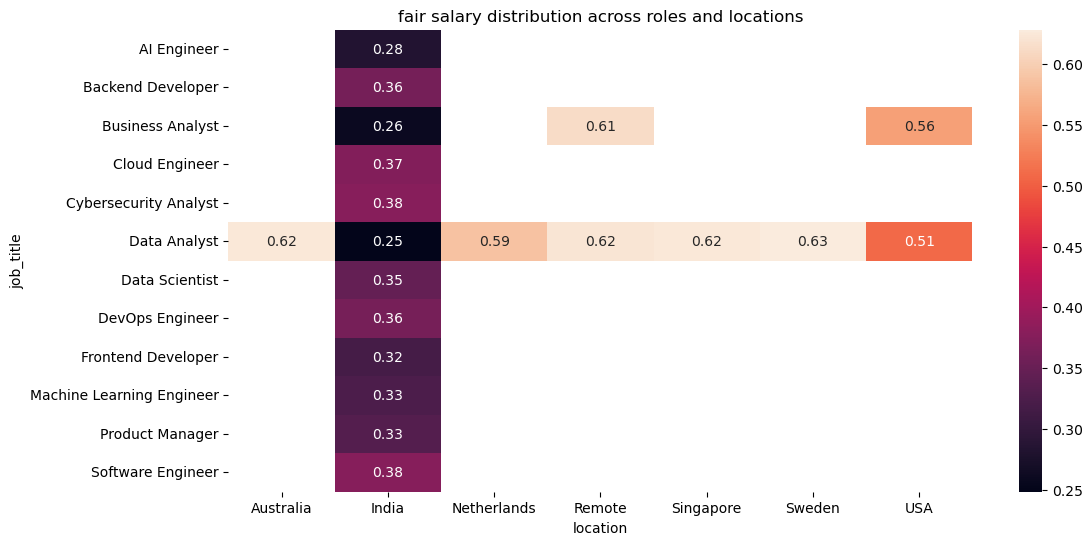

In [284]:
top=fairness_pivot.sort_values(ascending=True , by='fair' ).head(20)
heatmap_data = top.pivot(index='job_title',
                                    columns='location',
                                    values='fair')
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,annot=True)
plt.title("fair salary distribution across roles and locations")
plt.show()
# top

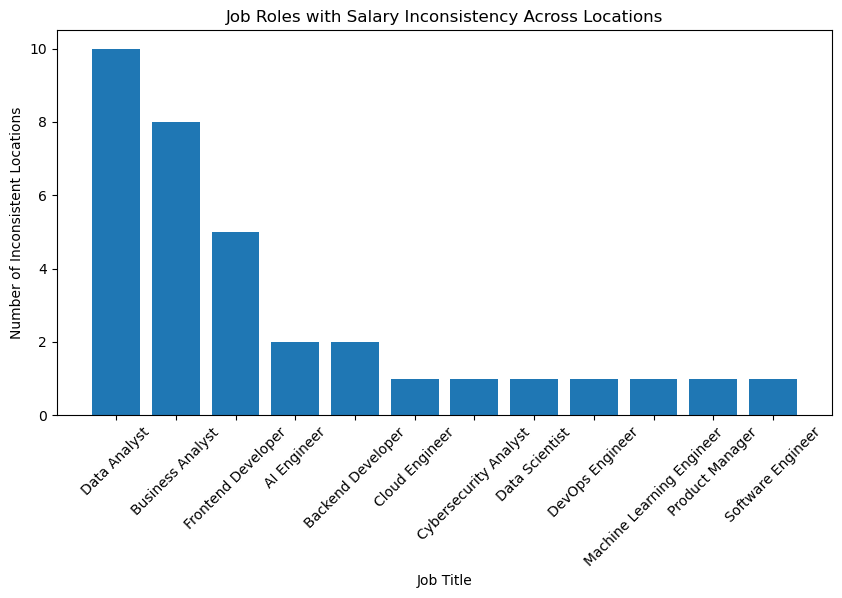

In [282]:
df_plot = no_of_inconsistency_over_locations.sort_values(by='count', ascending=False)

plt.figure(figsize=(10,5))
plt.bar(df_plot['job_title'], df_plot['count'])

plt.xticks(rotation=45)
plt.xlabel("Job Title")
plt.ylabel("Number of Inconsistent Locations")
plt.title("Job Roles with Salary Inconsistency Across Locations")

plt.show()

In [288]:
# plt.figure(figsize=(10,5))
# plt.barh(df_plot['job_title'], df_plot['count'])

# plt.xlabel("Number of Inconsistent Locations")
# plt.ylabel("Job Title")
# plt.title("Salary Instability Across Roles")

# plt.gca().invert_yaxis()

# plt.show()